# Projeto G2 - Análise da Qualidade do Ar no Brasil
# Disciplina: Linguagem de Programação

## Importação das bibliotecas

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"]=(10,6)

## Introdução ao problema

# Introdução

A qualidade do ar influencia diretamente a saúde humana e o meio ambiente.
Neste projeto será realizada uma análise exploratória dos dados de qualidade do ar
em cidades brasileiras, considerando diferentes poluentes e fatores ambientais.

Objetivos:

- Analisar indicadores de qualidade do ar
- Identificar regiões mais críticas
- Observar tendências temporais
- Construir KPIs
- Desenvolver dashboard interativo

## Explicação da base

# Descrição da Base

Variáveis:

- ano → ano da medição
- mes → mês da medição
- cidade → cidade monitorada
- regiao → região do Brasil
- pm25 → partículas PM2.5
- pm10 → partículas PM10
- no2 → dióxido de nitrogênio
- co → monóxido de carbono
- o3 → ozônio
- temperatura_media
- umidade
- indice_qualidade_ar
- nivel_qualidade

## Carregamento dos dados

In [12]:
df = pd.read_csv("/content/simulacao_qualidade_ar_brasil.csv")

df.head()

,ano,mes,data,regiao,uf,cidade,pm25,pm10,no2,co,o3,temperatura_media,umidade,indice_qualidade_ar,nivel_qualidade
0,2015,1,2015-01-01,Norte,AM,Manaus,40.49,59.71,36.34,1.65,41.76,27.5,40.7,77.83,Moderada
1,2015,1,2015-01-01,Norte,PA,Belém,42.40,56.33,11.07,0.76,57.16,25.3,76.2,66.82,Moderada
2,2015,1,2015-01-01,Norte,PA,Santarém,33.09,67.08,14.03,1.03,34.61,27.4,91.8,61.79,Moderada
3,2015,1,2015-01-01,Norte,RO,Porto Velho,28.57,92.40,19.51,1.38,22.36,19.6,57.7,66.96,Moderada
4,2015,1,2015-01-01,Norte,TO,Palmas,22.18,92.50,28.23,1.63,27.42,23.4,47.3,65.93,Moderada


## Informações gerais

In [13]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ano                  4440 non-null   int64  
 1   mes                  4440 non-null   int64  
 2   data                 4440 non-null   object 
 3   regiao               4440 non-null   object 
 4   uf                   4440 non-null   object 
 5   cidade               4440 non-null   object 
 6   pm25                 4440 non-null   float64
 7   pm10                 4440 non-null   float64
 8   no2                  4440 non-null   float64
 9   co                   4440 non-null   float64
 10  o3                   4440 non-null   float64
 11  temperatura_media    4440 non-null   float64
 12  umidade              4440 non-null   float64
 13  indice_qualidade_ar  4440 non-null   float64
 14  nivel_qualidade      4440 non-null   object 
dtypes: float64(8), int64(2), object(5)
mem

,ano,mes,pm25,pm10,no2,co,o3,temperatura_media,umidade,indice_qualidade_ar
count,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000
mean,2019.500000,6.500000,35.064973,70.033644,24.863036,1.055745,40.131635,25.012613,67.521622,67.742243
std,2.872605,3.452441,9.111828,18.269480,7.957356,0.430307,10.032435,2.973427,15.900387,10.277948
min,2015.000000,1.000000,3.670000,3.000000,1.000000,0.300000,4.620000,13.000000,40.000000,29.650000
25%,2017.000000,3.750000,28.817500,57.887500,19.340000,0.680000,33.390000,23.000000,53.800000,60.955000
50%,2019.500000,6.500000,35.020000,70.065000,24.700000,1.050000,40.470000,25.000000,67.700000,67.535000
75%,2022.000000,9.250000,41.080000,82.272500,30.530000,1.430000,46.690000,27.100000,81.300000,74.685000
max,2024.000000,12.000000,75.130000,138.250000,52.780000,1.800000,80.900000,37.700000,95.000000,107.230000


## Verificar valores ausentes

In [14]:
df.isnull().sum()

,0
ano,0
mes,0
data,0
regiao,0
uf,0
cidade,0
pm25,0
pm10,0
no2,0
co,0


## Limpeza e preparação

In [15]:
df["data"]=pd.to_datetime(df["data"])

df["mes_nome"]=df["data"].dt.month_name()

df.head()

,ano,mes,data,regiao,uf,cidade,pm25,pm10,no2,co,o3,temperatura_media,umidade,indice_qualidade_ar,nivel_qualidade,mes_nome
0,2015,1,2015-01-01,Norte,AM,Manaus,40.49,59.71,36.34,1.65,41.76,27.5,40.7,77.83,Moderada,January
1,2015,1,2015-01-01,Norte,PA,Belém,42.40,56.33,11.07,0.76,57.16,25.3,76.2,66.82,Moderada,January
2,2015,1,2015-01-01,Norte,PA,Santarém,33.09,67.08,14.03,1.03,34.61,27.4,91.8,61.79,Moderada,January
3,2015,1,2015-01-01,Norte,RO,Porto Velho,28.57,92.40,19.51,1.38,22.36,19.6,57.7,66.96,Moderada,January
4,2015,1,2015-01-01,Norte,TO,Palmas,22.18,92.50,28.23,1.63,27.42,23.4,47.3,65.93,Moderada,January


## Engenharia de atributos

In [16]:
df["estacao"] = np.where(
    df["mes"].isin([12,1,2]),
    "Verão",
    np.where(
        df["mes"].isin([3,4,5]),
        "Outono",
        np.where(
            df["mes"].isin([6,7,8]),
            "Inverno",
            "Primavera"
        )
    )
)

df.head()

,ano,mes,data,regiao,uf,cidade,pm25,pm10,no2,co,o3,temperatura_media,umidade,indice_qualidade_ar,nivel_qualidade,mes_nome,estacao
0,2015,1,2015-01-01,Norte,AM,Manaus,40.49,59.71,36.34,1.65,41.76,27.5,40.7,77.83,Moderada,January,Verão
1,2015,1,2015-01-01,Norte,PA,Belém,42.40,56.33,11.07,0.76,57.16,25.3,76.2,66.82,Moderada,January,Verão
2,2015,1,2015-01-01,Norte,PA,Santarém,33.09,67.08,14.03,1.03,34.61,27.4,91.8,61.79,Moderada,January,Verão
3,2015,1,2015-01-01,Norte,RO,Porto Velho,28.57,92.40,19.51,1.38,22.36,19.6,57.7,66.96,Moderada,January,Verão
4,2015,1,2015-01-01,Norte,TO,Palmas,22.18,92.50,28.23,1.63,27.42,23.4,47.3,65.93,Moderada,January,Verão


## KPIs

In [17]:
media_iqa=df["indice_qualidade_ar"].mean()

cidade_mais_poluida=df.groupby(
    "cidade"
)["indice_qualidade_ar"].mean().idxmax()

pm25_medio=df["pm25"].mean()

total_cidades=df["cidade"].nunique()

print("Média IQA:",round(media_iqa,2))
print("Cidade mais poluída:",cidade_mais_poluida)
print("PM2.5 médio:",round(pm25_medio,2))
print("Número de cidades:",total_cidades)

Média IQA: 67.74
Cidade mais poluída: Florianópolis
PM2.5 médio: 35.06
Número de cidades: 37


## Gráfico por região

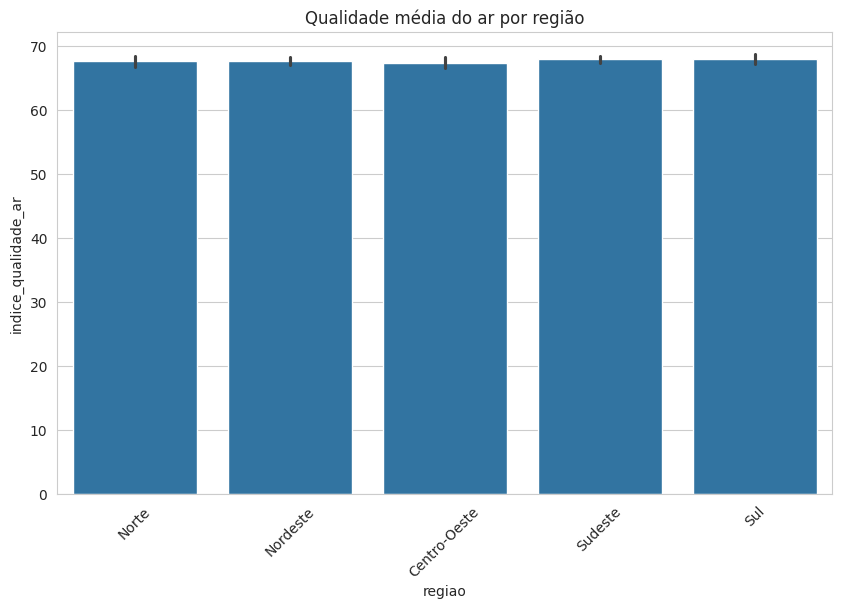

In [18]:
sns.barplot(
    data=df,
    x="regiao",
    y="indice_qualidade_ar"
)

plt.title("Qualidade média do ar por região")

plt.xticks(rotation=45)

plt.show()

## Evolução temporal

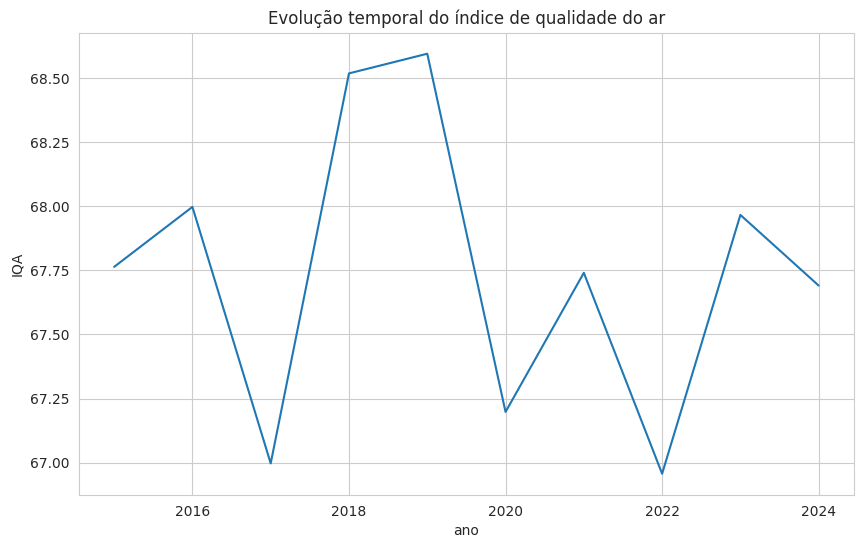

In [19]:
serie=df.groupby(
    "ano"
)["indice_qualidade_ar"].mean()

serie.plot()

plt.title("Evolução temporal do índice de qualidade do ar")

plt.ylabel("IQA")

plt.show()

## Correlação estatística

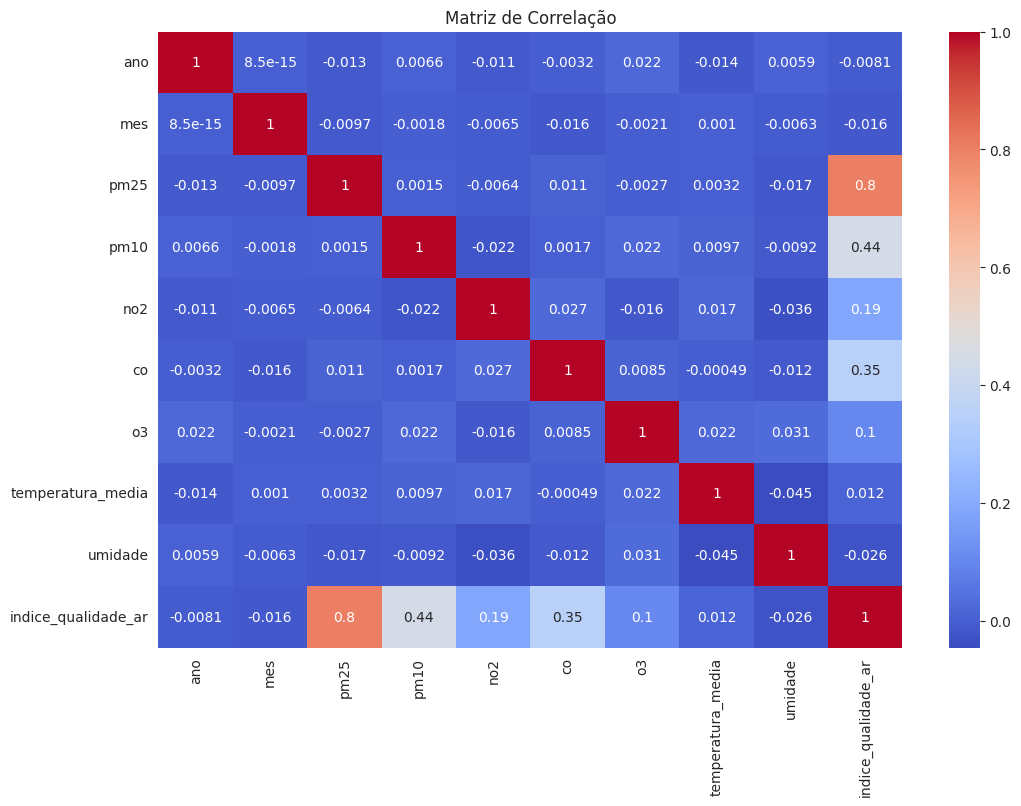

In [20]:
correlacao=df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de Correlação")

plt.show()

## Interpretação

# Interpretação dos resultados

- Algumas regiões apresentam maior índice médio de poluição.
- Existe relação entre determinados poluentes.
- Alguns indicadores possuem correlação positiva.

# Conclusão

A análise permitiu identificar padrões relevantes sobre qualidade do ar nas regiões brasileiras.

Os resultados podem apoiar decisões ambientais e políticas públicas.